In [1]:
#@title Importing packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
import os
from google.colab import drive
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
# import tqdm
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [3]:
#@title Defining a time-dependent score-based model (double click to expand or collapse)

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]

class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    # Encoding layers where the resolution decreases
    self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])
    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
    self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
    self.dense4 = Dense(embed_dim, channels[3])
    self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

    # Decoding layers where the resolution increases
    self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
    self.dense5 = Dense(embed_dim, channels[2])
    self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
    self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
    self.dense6 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
    self.dense7 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std

  def forward(self, x, t):
    # Obtain the Gaussian random feature embedding for t
    embed = self.act(self.embed(t))
    # Encoding path
    h1 = self.conv1(x)
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)
    h2 = self.conv2(h1)
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)
    h3 = self.conv3(h2)
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
    h4 = self.conv4(h3)
    h4 += self.dense4(embed)
    h4 = self.gnorm4(h4)
    h4 = self.act(h4)

    # Decoding path
    h = self.tconv4(h4)
    ## Skip connection from the encoding path
    h += self.dense5(embed)
    h = self.tgnorm4(h)
    h = self.act(h)
    h = self.tconv3(torch.cat([h, h3], dim=1))
    h += self.dense6(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
    h = self.tconv2(torch.cat([h, h2], dim=1))
    h += self.dense7(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    h = self.tconv1(torch.cat([h, h1], dim=1))

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

In [4]:
#@title Set up the SDE
# value of sigma is 25
def marginal_prob_std(t, sigma):
  t = torch.tensor(t, device=device)
  return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
  return torch.tensor(sigma**t, device=device)

In [5]:
#@title Marginal, Diffusion Sigma
sigma =  25
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

In [6]:
#@title Loss function
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model(perturbed_x, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

In [7]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/dibyanshushekhardey/mnist-even-model/ckpt_even.pth


In [8]:
model_path = "/kaggle/input/datasets/dibyanshushekhardey/mnist-even-model/ckpt_even.pth"
checkpoint = torch.load(
    model_path,
    map_location=device
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [9]:
score_model = torch.nn.DataParallel(
    ScoreNet(marginal_prob_std=marginal_prob_std_fn)
)
print(type(checkpoint))
score_model = score_model.to(device)

# Load weights
score_model.load_state_dict(torch.load(model_path,map_location=device))
score_model.eval()

<class 'collections.OrderedDict'>


DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense4): Dense(
      (dense): Linear(in_features=256, out_features=256,

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.71MB/s]


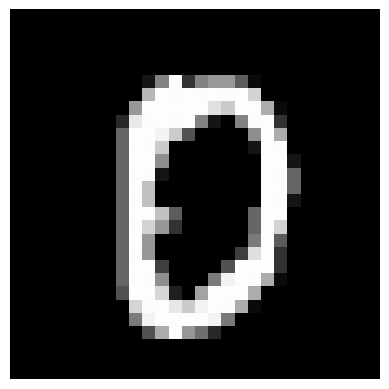

In [10]:
#@title MNIST Dataset loading
batch_size=128
train_dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
even_indices = [i for i, (_, label) in enumerate(train_dataset) if label % 2 == 0]
even_dataset = Subset(train_dataset, even_indices)
data_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
images, labels = next(iter(data_loader))
x0 = images[0]
x0 = x0.unsqueeze(0).to(device)
plt.imshow(x0.squeeze().cpu(), cmap='gray')
plt.axis('off')
plt.show()

In [11]:
#@title masking operators
class GaussianDenoisingOperator:
    def forward(self, x):
        return x

class InpaintingOperator:
    def __init__(self, mask):
        self.mask = mask

    def forward(self, x):
        return self.mask * x

In [12]:
#@title Tweedie Estimate
def compute_x0_hat(x_t, t, score):
    # Tweedie's formula
    sigma_t = marginal_prob_std_fn(t)
    sigma_t = sigma_t[:,None,None,None]
    return x_t + sigma_t**2 * score

#@title Measurement Loss
def measurement_loss(y, x0_hat, operator):
    y_hat = operator.forward(x0_hat)
    return ((y - y_hat)**2).sum()

#@title Gradient Calculation
def compute_gradient(x_t, y, operator, t):
    x_t.requires_grad_(True)
    score = score_model(x_t, t)
    x0_hat = compute_x0_hat(x_t,t, score)
    y_hat = operator.forward(x0_hat)
    loss = ((y - y_hat)**2).sum()
    grad = torch.autograd.grad(loss,x_t)[0]

    return grad, x0_hat

#@title Step size calculation
def compute_step_size(y,x0_hat,operator,zeta_prime):
    residual = y - operator.forward(x0_hat)
    return zeta_prime / (residual.norm() + 1e-8)

def reverse_sde_step(x_t, score, t, dt):
    g = diffusion_coeff_fn(t)
    if g.ndim == 0:
        g = g.view(1)
    g = g[:, None, None, None]
    noise = torch.randn_like(x_t)
    x_mean = x_t + g**2 * score * dt
    x = x_mean + g * torch.sqrt(dt) * noise
    return x, x_mean

In [13]:
def dps_sampler(y,operator, num_steps=1000,zeta_prime=0.01):
    #torch.manual_seed(42)
    t_init = torch.ones(y.shape[0],device=device)
    init_std = marginal_prob_std_fn(t_init)

    init_std = init_std[:,None,None,None].to(y.device)

    x_t = torch.randn_like(y) * init_std
    time_steps = torch.linspace(1.0,1e-3,num_steps,device=device)
    dt = time_steps[0] - time_steps[1]

    for step, t in enumerate(time_steps):
        t_batch = torch.ones(x_t.shape[0],device=device) * t
        score = score_model(x_t,t_batch)
        x_prime,_ = reverse_sde_step(x_t,score,t,dt)
        grad, x0_hat = compute_gradient( x_t,y, operator,t_batch)
        step_size = compute_step_size(y,x0_hat,operator,zeta_prime).to(device)
        x_t = (x_prime- step_size * grad).detach()

    return x0_hat

In [14]:
zeta_prime_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
num_samples = 100
sigma_y = 0.2
y = x0 + sigma_y * torch.randn_like(x0).to(device)
operator = GaussianDenoisingOperator()
y_batch = y.repeat(num_samples, 1, 1, 1).to(device)

posterior_means = {}

for zeta in zeta_prime_list:
    print(f"Running zeta_prime = {zeta}")
    x_hat = dps_sampler(y_batch,operator,num_steps=1000,zeta_prime=zeta)
    posterior_means[zeta] = (x_hat.mean(dim=0, keepdim=True).detach().cpu())
    print(f"Finished zeta_prime = {zeta}")

Running zeta_prime = 0.001


/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


Finished zeta_prime = 0.001
Running zeta_prime = 0.005
Finished zeta_prime = 0.005
Running zeta_prime = 0.01
Finished zeta_prime = 0.01
Running zeta_prime = 0.05
Finished zeta_prime = 0.05
Running zeta_prime = 0.1
Finished zeta_prime = 0.1
Running zeta_prime = 0.5
Finished zeta_prime = 0.5
Running zeta_prime = 1
Finished zeta_prime = 1
Running zeta_prime = 5
Finished zeta_prime = 5
Running zeta_prime = 10
Finished zeta_prime = 10


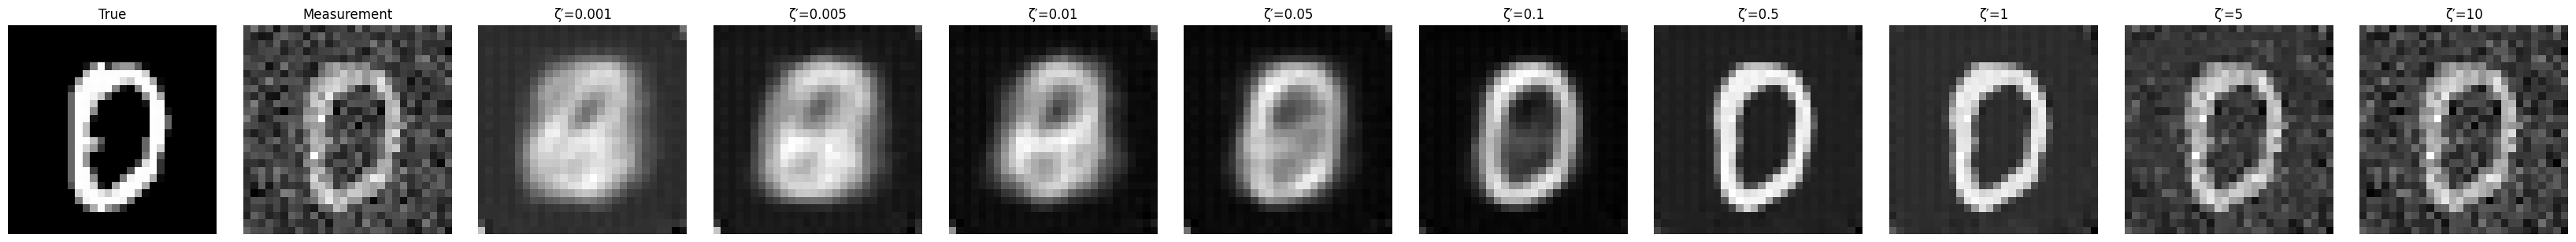

In [15]:
import matplotlib.pyplot as plt

ncols = len(zeta_prime_list) + 2
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
# True image
ax[0].imshow(x0[0,0].detach().cpu().numpy(),cmap='gray')
ax[0].set_title("True")
# Measurement
ax[1].imshow(y[0,0].detach().cpu().numpy(),cmap='gray')
ax[1].set_title("Measurement")
# Posterior means
for i, zeta in enumerate(zeta_prime_list):
    ax[i+2].imshow(posterior_means[zeta][0,0].detach().cpu().numpy(),cmap='gray')
    ax[i+2].set_title(f"ζ′={zeta}")
for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig("Gaussian_posterior_mean_different_zeta_prime.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
from skimage.metrics import structural_similarity as ssim
import math

def compute_ssim(x_true, x_pred):
    x_true = x_true.detach().squeeze().cpu().numpy()
    #x_pred = x_pred.squeeze().cpu().numpy()
    x_pred = x_pred.detach().squeeze().cpu().numpy()
    return ssim(x_true,x_pred,data_range=x_true.max() - x_true.min())

def psnr(x_true, x_pred, max_val=1.0):
    mse = torch.mean((x_true - x_pred) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val / math.sqrt(mse.item()))

In [17]:
metrics = {}

for zeta in zeta_prime_list:
    posterior_mean = posterior_means[zeta]
    metrics[zeta] = {
        "PSNR": psnr(x0.cpu(), posterior_mean),
        "SSIM": compute_ssim(x0.cpu(), posterior_mean)
    }

for zeta in zeta_prime_list:
    print(
        f"ζ′={zeta:<6} "
        f"PSNR={metrics[zeta]['PSNR']:.2f} dB  "
        f"SSIM={metrics[zeta]['SSIM']:.4f}"
    )

ζ′=0.001  PSNR=11.53 dB  SSIM=0.2584
ζ′=0.005  PSNR=11.78 dB  SSIM=0.2935
ζ′=0.01   PSNR=11.74 dB  SSIM=0.3008
ζ′=0.05   PSNR=13.05 dB  SSIM=0.4429
ζ′=0.1    PSNR=15.98 dB  SSIM=0.6781
ζ′=0.5    PSNR=23.92 dB  SSIM=0.9147
ζ′=1      PSNR=23.87 dB  SSIM=0.9132
ζ′=5      PSNR=17.47 dB  SSIM=0.7561
ζ′=10     PSNR=14.64 dB  SSIM=0.6956


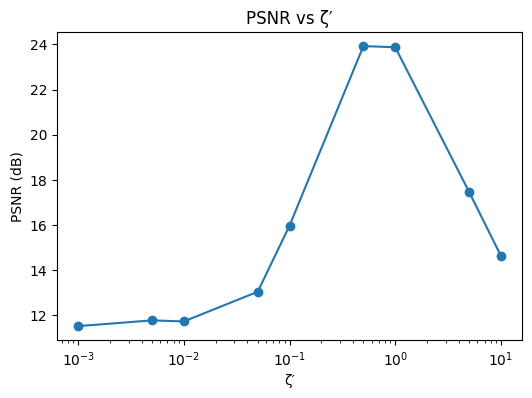

In [18]:
psnr_values = [metrics[z]["PSNR"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, psnr_values, marker='o')
plt.xscale('log')  # useful since zeta spans several orders
plt.xlabel("ζ′")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs ζ′")
plt.grid(False)
plt.savefig("PSNR_Gaussian_dps.png", dpi=300, bbox_inches="tight")
plt.show()

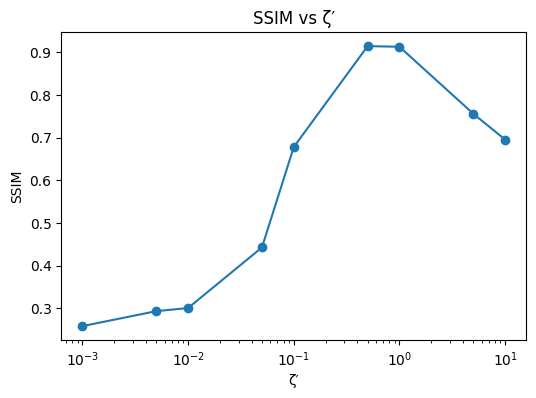

In [19]:
ssim_values = [metrics[z]["SSIM"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, ssim_values, marker='o')
plt.xscale('log')
plt.xlabel("ζ′")
plt.ylabel("SSIM")
plt.title("SSIM vs ζ′")
plt.grid(False)
plt.savefig("SSIM_Gaussian_dps.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
sigma_y = 0.2
y = x0 + sigma_y * torch.randn_like(x0).to(device)
operator = GaussianDenoisingOperator()
num_samples = 100
y_batch = y.repeat(num_samples, 1, 1, 1).to(device)
x_hat = dps_sampler(y_batch,operator,num_steps=1000,zeta_prime=0.5)

/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


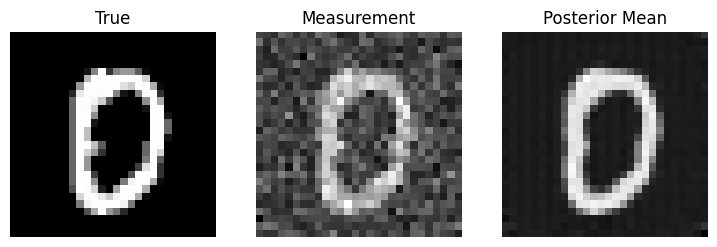

In [21]:
posterior_mean = x_hat.mean(dim=0, keepdim=True)
fig, ax = plt.subplots(1,3, figsize=(9,3))

ax[0].imshow(x0[0,0].cpu(), cmap='gray')
ax[0].set_title("True")

ax[1].imshow(y[0,0].cpu(), cmap='gray')
ax[1].set_title("Measurement")

ax[2].imshow(posterior_mean[0,0].detach().cpu(),cmap='gray')
ax[2].set_title("Posterior Mean")

for a in ax:
    a.axis('off')
plt.savefig("Gaussian_posterior_mean_single_digit.png", dpi=300,  bbox_inches='tight')
plt.show()

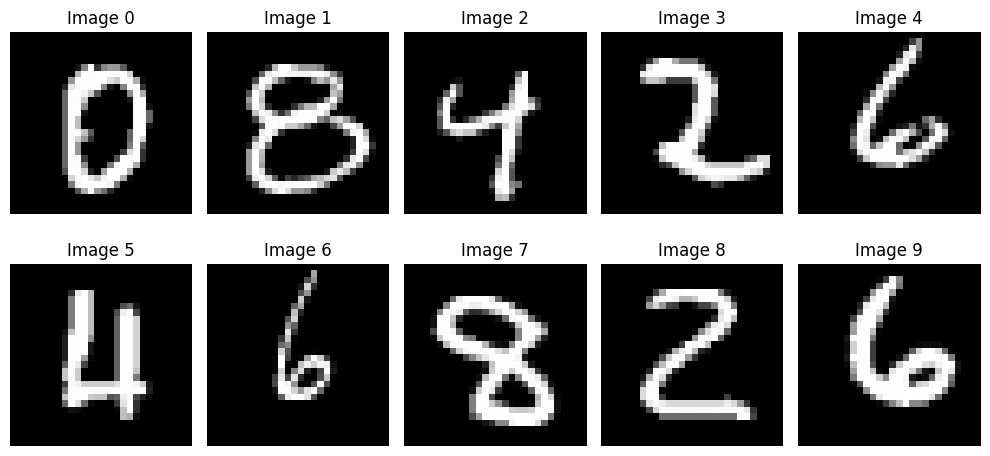

In [22]:
x0 = images[0:10].to(device)
fig, ax = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    ax[i // 5, i % 5].imshow(x0[i, 0].cpu(),cmap='gray')
    ax[i // 5, i % 5].set_title(f"Image {i}")
    ax[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.show()

In [23]:
sigma_y = 0.2
num_digits = 10
num_posterior_samples = 100
tau_prime = 0.5
num_steps = 1000

x0_batch = x0[0:10].to(device)
posterior_means = []

for i in tqdm(range(num_digits)):
    # One digit
    x0_i = x0_batch[i]
    # One measurement for this digit
    y_i = x0_i + sigma_y * torch.randn_like(x0_i).to(device)
    operator = GaussianDenoisingOperator()
    # Generate 100 copies of the SAME measurement
    y_i_batch = y_i.repeat(num_posterior_samples, 1, 1, 1)

    # 100 stochastic DPS samples
    x_hat_i = dps_sampler(y_i_batch,operator,num_steps=num_steps,zeta_prime=tau_prime)
    # Posterior mean for this digit
    posterior_mean_i = x_hat_i.mean(dim=0,keepdim=True)
    posterior_means.append(posterior_mean_i.detach().cpu())
    del y_i_batch
    del x_hat_i
    torch.cuda.empty_cache()

posterior_means = torch.cat(posterior_means,dim=0)
print(posterior_means.shape)

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


torch.Size([10, 1, 28, 28])


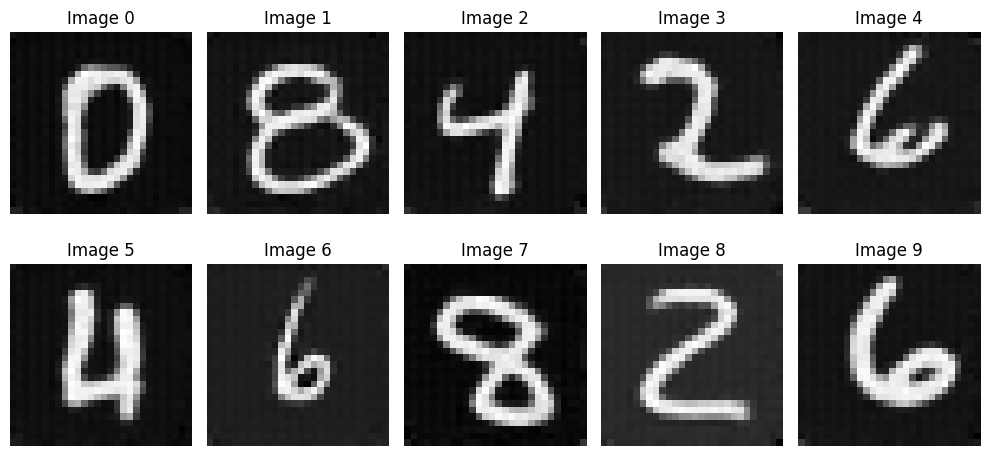

In [24]:
x_hat = posterior_means[0:10]

fig, ax = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    ax[i // 5, i % 5].imshow(x_hat[i, 0],cmap='gray')
    ax[i // 5, i % 5].set_title(f"Image {i}")
    ax[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.savefig("Posterior_means_dps_gauss_10.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
def median_heuristic(X):
    if X.dim() == 1:
        X = X.reshape(-1, 1)
    dists_sq = torch.cdist(X,X, p=2) ** 2
    H_n = torch.median(dists_sq)
    h = torch.sqrt(H_n / 2.0)
    return h

class PooledKSD:
    def __init__(self, means, sigmas, weights, device, model=None,):
        self.device = device

        self.means = torch.as_tensor(means, dtype=torch.float32, device=device)
        self.sigmas = torch.as_tensor(sigmas, dtype=torch.float32, device=device)
        self.weights = torch.as_tensor(weights, dtype=torch.float32, device=device)

        self.model = model
        self.use_denoiser = model is not None

        # setting denoiser to eval mode
        if self.use_denoiser:
            self.model.eval()

    def score_function(self, x, sigma_noise):
        # estimated score
        if self.use_denoiser:
            original_shape = x.shape
            x_flat = x.reshape(-1, x.shape[-1])
            sigma = torch.full_like(x_flat, sigma_noise)
            with torch.no_grad():
                score = self.model(x_flat, sigma)
            return score.reshape(original_shape)
        else:
            # analytic true score
            x_in = x.clone().detach().requires_grad_(True)
            x_flat = x_in.reshape(-1, x_in.shape[-1])

            means = self.means.view(1, -1)
            sigmas = self.sigmas.view(1, -1)
            weights = self.weights.view(1, -1)
            var = sigmas**2 + sigma_noise**2

            log_components = (torch.log(weights) - 0.5 * torch.log(2 * torch.pi * var) -
                             (x_flat - means)**2 / (2 * var))
            logp = torch.logsumexp(log_components, dim=1)
            score = torch.autograd.grad(logp.sum(), x_in, create_graph=True)[0]
            return score

    def rbf_kernel(self, x1, x2, scale):
        diff = x1 - x2
        return torch.exp(-(diff**2).sum(dim=-1) /(2*scale**2))
    def grad_x1_rbf(self, x1, x2, scale):
        k = self.rbf_kernel(x1, x2, scale)
        return ( -k.unsqueeze(-1)* (x1-x2) / scale**2)
    def grad_x2_rbf(self, x1, x2, scale):
        return -self.grad_x1_rbf( x1, x2, scale)

    def grad_x1_x2_rbf(self, x1, x2, scale):
        diff = x1-x2
        sq = (diff**2).sum(dim=-1)
        k = self.rbf_kernel(x1,x2,scale)
        d = diff.shape[-1]
        return (d/scale**2 -  sq/scale**4)*k

    def u_q(self, x1, x2,scale,sigma_l):
        score1 = self.score_function(x1, sigma_l)
        score2 = self.score_function(x2, sigma_l)
        k = self.rbf_kernel(x1,x2,scale)
        grad1 = self.grad_x1_rbf(x1,x2,scale)
        grad2 = self.grad_x2_rbf( x1,x2,scale)
        grad12 = self.grad_x1_x2_rbf(x1,x2,scale)
        return ((score1*score2).sum(dim=-1)*k + (score1*grad2).sum(dim=-1) + (grad1*score2).sum(dim=-1) + grad12)

    def bootstrap_stat(self, U):
        n = U.shape[0]
        probs = torch.ones(n, device=self.device) / n
        samples = torch.multinomial(probs, num_samples=n, replacement=True)
        w = torch.bincount(samples, minlength=n).float()
        w_centered = (w / n) - (1.0 / n)
        S = w_centered @ U @ w_centered
        diag_correction = torch.sum(w_centered ** 2 * torch.diag(U))
        return S - diag_correction

    def compute_ksd(self, samples, scale):
        samples = samples.to(self.device)
        n = samples.shape[0]
        x_i = samples[:, None, :]
        x_j = samples[None, :, :]
        U = self.u_q(x_i, x_j, scale)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        return ksd, U

    def pooled_test(self, x_ksd, sigma_list, alpha=0.05, num_boot=300):
        n = x_ksd.shape[0]
        U = torch.zeros((n, n), device=x_ksd.device)
        for sigma_l in sigma_list:
            epsilon = torch.randn_like(x_ksd)
            x_i_tilde = x_ksd + sigma_l * epsilon
            x1 = x_i_tilde[:, None, :]
            x2 = x_i_tilde[None, :, :]
            scale = median_heuristic(x_ksd)
            scale = torch.clamp(scale, min=1e-3)
            U += self.u_q(x1, x2, scale, sigma_l)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        boot_stats = torch.stack([self.bootstrap_stat(U) for _ in range(num_boot)])
        critical_val = torch.quantile(boot_stats, 1 - alpha)
        reject = (ksd > critical_val).int()
        return reject, ksd, critical_val, boot_stats

class ScoreKSD(PooledKSD):
    def __init__(self, score_model, device, image_shape=None):
        # Dummy GMM parameters – not used because we override score_function
        super().__init__(means=[0.0], sigmas=[1.0], weights=[1.0],
                         device=device, model=None)
        self.score_model = score_model
        self.score_model.eval()
        self.image_shape = image_shape  # e.g., (1, 28, 28) or (3, 32, 32)
        self.current_t = None           # default noise level

    def score_function(self, x, sigma_noise=None):
        if sigma_noise is None:
            if self.current_t is None:
                raise ValueError("sigma_noise must be provided or set current_t")
            sigma_noise = self.current_t

        x = x.to(self.device)
        original_shape = x.shape # (n, 1, d) or (1, n, d)
        # Flatten all but last dimension into batch
        x_flat = x.reshape(-1, x.shape[-1])          # (total_batch, d)
        # Convert to images if needed
        if self.image_shape is not None:
            x_img = x_flat.reshape(-1, *self.image_shape)
        else:
            x_img = x_flat
        t = torch.full((x_flat.shape[0],), sigma_noise,
                       device=self.device, dtype=x.dtype)
        with torch.no_grad():
            score = self.score_model(x_img, t)       # same shape as x_img
        # Flatten score to (total_batch, d)
        score_flat = score.reshape(x_flat.shape[0], -1)
        # Reshape back to the original shape of x
        return score_flat.reshape(original_shape)

    def compute_ksd_with_t(self, samples, t, h=None):
        samples = samples.to(self.device)
        n = samples.shape[0]
        # Flatten if needed
        if samples.dim() > 2:
            samples = samples.reshape(n, -1)
        # Bandwidth
        if h is None:
            h = median_heuristic(samples)
            h = max(h, 1e-3)          # stability
        scale = torch.tensor(h, device=self.device, dtype=samples.dtype)

        # Build U using u_q with sigma_l = t (this will call the neural score because ScoreKSD overrides score_function)
        x1 = samples.unsqueeze(1)      # (n, 1, d)
        x2 = samples.unsqueeze(0)      # (1, n, d)
        U = self.u_q(x1, x2, scale, sigma_l=t)

        U.fill_diagonal_(0)            # KSD uses i ≠ j
        ksd = U.sum() / (n * (n - 1))
        return ksd.item(), U

In [28]:
from torch.utils.data import TensorDataset


Processing t = 0.25


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/2114037847.py:156: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.tensor(h, device=self.device, dtype=samples.dtype)



Processing t = 0.27


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.37


  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.4


  0%|          | 0/100 [00:00<?, ?it/s]

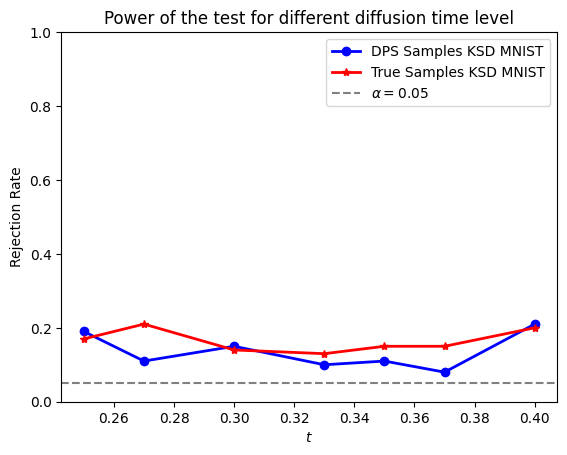

In [36]:
num_trials = 100
n = 10
t_values = [0.25, 0.27, 0.3, 0.33, 0.35, 0.37, 0.4]
num_boot = 200
num_step = 20
alpha = 0.05
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x0 = images[0:10].to(device)
posterior_means = posterior_means[0:10].to(device)   # [10,1,28,28]
# true_dataset = TensorDataset(x0)
# true_loader = DataLoader(true_dataset,batch_size=10,shuffle=True)
# dps_dataset = TensorDataset(posterior_means)
# dps_loader = DataLoader(dps_dataset,batch_size=10,shuffle=True)
paired_dataset = TensorDataset(x0, posterior_means)
paired_loader = DataLoader(paired_dataset,batch_size=10,shuffle=True)
ksd_test = ScoreKSD(score_model=score_model, device=device, image_shape=(1, 28, 28))

def sample_null(n, t):
    x_real,_ = next(iter(paired_loader))
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    noise = torch.randn_like(x_real)
    x_noisy = x_real + std[:, None, None, None] * noise
    return x_noisy.view(n, -1)

def sample_alt(n, t):
    _,x_dps = next(iter(paired_loader))
    x_dps = x_dps[:n].to(device)
    t_batch = torch.ones(x_dps.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    noise = torch.randn_like(x_dps)
    x_noisy = x_dps + std[:, None, None, None] * noise
    return x_noisy.view(n, -1)

# Compute rejection rates for each t 
rejection_rates_alt = []
rejection_rates_null = []
for t in t_values:
    print(f"\nProcessing t = {t}")
    rejections_null = []
    rejections_alt = []
    for rep in tqdm(range(num_trials)):
        # null
        X_null = sample_null(n, t)
        ksd_null, U_null = ksd_test.compute_ksd_with_t(X_null, t=t)
        boot_stats_null = torch.stack([ksd_test.bootstrap_stat(U_null) for _ in range(num_boot)])
        critical_val_null = torch.quantile(boot_stats_null, 1 - alpha)
        reject_null = (ksd_null > critical_val_null).int()
        rejections_null.append(reject_null.item())
        
        # alternative
        X_alt = sample_alt(n, t)
        ksd_alt, U_alt = ksd_test.compute_ksd_with_t(X_alt, t=t)
        boot_stats_alt = torch.stack([ksd_test.bootstrap_stat(U_alt) for _ in range(num_boot)])
        critical_val_alt = torch.quantile(boot_stats_alt, 1 - alpha)
        reject_alt = (ksd_alt > critical_val_alt).int()
        rejections_alt.append(reject_alt.item())
        
    rejection_rates_null.append(np.mean(rejections_null))
    rejection_rates_alt.append(np.mean(rejections_alt))
    
plt.plot(t_values, rejection_rates_alt, marker='o', linewidth=2, label='DPS Samples KSD MNIST', color='blue')
plt.plot(t_values, rejection_rates_null, marker='*', linewidth=2, label='True Samples KSD MNIST', color='red')
plt.axhline(0.05, color='gray', linestyle='--', label=r'$\alpha=0.05$')
plt.xlabel(r'$t$')
plt.ylabel("Rejection Rate")
plt.title(r"Power of the test for different diffusion time level")
plt.legend()
plt.grid(False)
plt.ylim(0, 1)
plt.savefig("ksd_score_dps_gauss_even.png", dpi=300, bbox_inches='tight')
plt.show()
